**Начало работы и анализ [настоящего датасета](./defefcts.csv) содержится в файле [MLdefectDataset](./MLdefectDataset.ipynb). В этом ноутбке представлена реализация обучения MLP**

In [1]:
import pandas as pd
import numpy as np
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
batch_size = 64

In [3]:
df = pd.read_csv("defefcts.csv")

X, y = df.drop('defect', axis=1), df['defect']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

sc = StandardScaler()
X_train_std = torch.from_numpy(sc.fit_transform(X_train).astype(np.float32))
X_test_std = torch.from_numpy(sc.transform(X_test).astype(np.float32))
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

dataset = TensorDataset(X_train_std, y_train_tensor)

torch.manual_seed(1)
dataLoader = DataLoader(dataset, batch_size, shuffle=True)

In [4]:
inp_size = X_train_std.shape[1]

In [5]:
import torch.nn as nn

In [6]:
model_base = nn.Sequential(
    nn.Linear(inp_size, 20),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(20, 1),
)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_base.parameters(), weight_decay=1e-4)

In [7]:
from sklearn.metrics import roc_auc_score

In [8]:
num_epochs = 200
loss_hist_train = [0] * num_epochs
loss_hist_valid = [0] * num_epochs
roc_hist_train = [0] * num_epochs
roc_hist_valid = [0] * num_epochs

amount_batchs = len(dataLoader)

In [9]:
def train(model, num_epochs, train_dl, x_valid, y_valid, optimizer, loss_fn):
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()
            roc_hist_train[epoch] += roc_auc_score(y_batch.numpy(), pred.detach().numpy()) 
        loss_hist_train[epoch] /= amount_batchs
        roc_hist_train[epoch] /= amount_batchs

        model.eval()
        with torch.no_grad():
            y_pred = model(x_valid).detach().flatten()

        loss_hist_valid[epoch] = loss_fn(y_pred, y_valid).item()
        roc_hist_valid[epoch] = roc_auc_score(y_valid.cpu().numpy(), y_pred)

In [10]:
train(model_base, num_epochs, dataLoader, X_test_std, y_test_tensor, optimizer, loss_fn)

In [11]:
import matplotlib.pyplot as plt

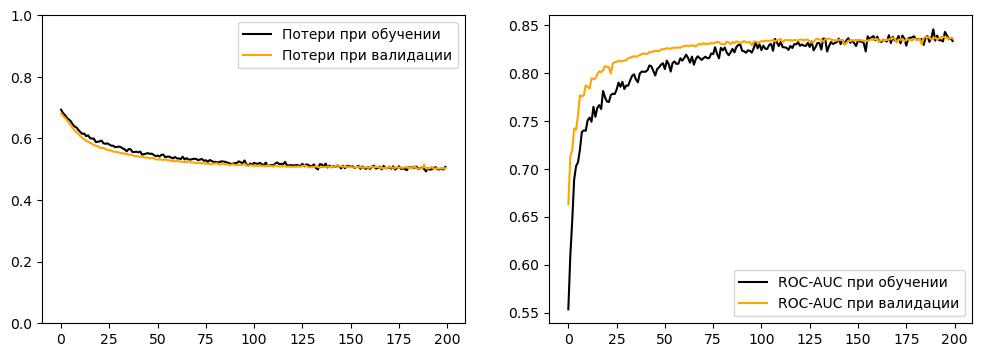

In [12]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1,2 ,1)
plt.ylim([0.0, 1.0])
plt.plot(loss_hist_train, color='Black')
plt.plot(loss_hist_valid, color='Orange')
plt.legend(['Потери при обучении', 'Потери при валидации'])
ax = fig.add_subplot(1,2,2)
plt.plot(roc_hist_train, color='Black')
plt.plot(roc_hist_valid, color='orange')
plt.legend(['ROC-AUC при обучении', 'ROC-AUC при валидации'])
plt.show()

In [13]:
y_pred = model_base(X_test_std).detach().cpu().numpy().flatten()
roc_auc_score(y_test, y_pred)

0.8361601040222503

In [15]:
significant_features = ['nosi', 'cbo', 'dit', 'rfc']

X_train_significant = X_train[significant_features]
X_test_significant = X_test[significant_features]

sc_significant = StandardScaler()
X_train_std_sign = torch.from_numpy(sc_significant.fit_transform(X_train_significant).astype(np.float32))
X_test_std_sign = torch.from_numpy(sc_significant.transform(X_test_significant).astype(np.float32))

dataset_sign = TensorDataset(X_train_std_sign, y_train_tensor)

dataLoader_sign = DataLoader(dataset_sign, batch_size, shuffle=True)

inp_size = X_test_significant.shape[1]

In [16]:
model_sign = nn.Sequential(
    nn.Linear(inp_size, 20),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(20, 1),
)

In [17]:
loss_hist_train = [0] * num_epochs
loss_hist_valid = [0] * num_epochs
roc_hist_train = [0] * num_epochs
roc_hist_valid = [0] * num_epochs

In [18]:
optimizer_t = torch.optim.Adam(model_sign.parameters(), weight_decay=1e-4)
loss_fn_t = nn.BCEWithLogitsLoss()

In [19]:
train(model_sign, num_epochs, dataLoader_sign, X_test_std_sign, y_test_tensor, optimizer_t, loss_fn_t)

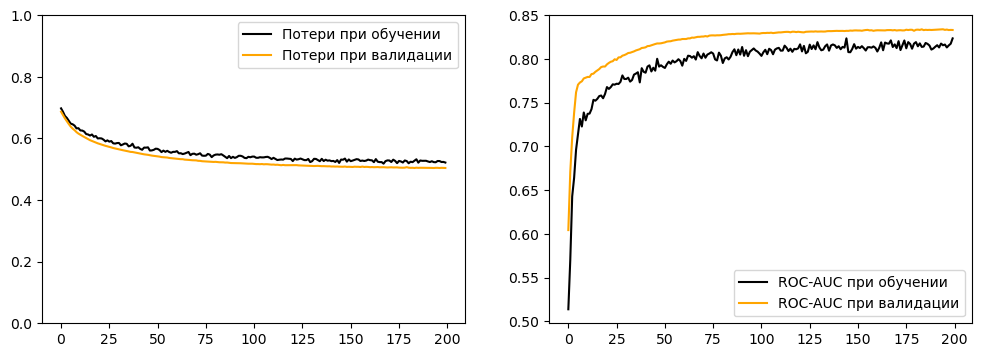

In [20]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1,2 ,1)
plt.ylim([0.0, 1.0])
plt.plot(loss_hist_train, color='Black')
plt.plot(loss_hist_valid, color='Orange')
plt.legend(['Потери при обучении', 'Потери при валидации'])
ax = fig.add_subplot(1,2,2)
plt.plot(roc_hist_train, color='Black')
plt.plot(roc_hist_valid, color='orange')
plt.legend(['ROC-AUC при обучении', 'ROC-AUC при валидации'])
plt.show()

In [21]:
y_pred = model_sign(X_test_std_sign).detach().cpu().numpy().flatten()
roc_auc_score(y_test, y_pred)

0.8332726860325628